In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 

param_recovery_250 = pd.read_csv("recovery_results_1000_data/recovery_results_1000_data_compact.csv")
param_recovery_eta_15 = pd.read_csv("/users/azhan378/data/azhang/efficient-fpt/examples/param_recovery_scripts/recovery_results_eta_15/recovery_results_eta_15_compact.csv")

param_recovery_a_simulate_2 = pd.read_csv("/users/azhan378/data/azhang/efficient-fpt/examples/param_recovery_scripts/recovery_results_a_simulate_2/recovery_results_a_simulate_2_compact.csv")
param_recovery_kappa_simulate_2 = pd.read_csv("/users/azhan378/data/azhang/efficient-fpt/examples/param_recovery_scripts/recovery_results_kappa_simulate_2/recovery_results_kappa_simulate_2_compact.csv")
param_recovery_x0_simulate_2 = pd.read_csv("/users/azhan378/data/azhang/efficient-fpt/examples/param_recovery_scripts/recovery_results_x0_simulate_2/recovery_results_x0_simulate_2_compact.csv")

In [3]:
# param_recovery_250
param_recovery_250_clean = param_recovery_250.dropna(subset=['addm_eta'])
param_recovery_15_clean = param_recovery_eta_15.dropna(subset=['addm_eta'])
# param_recovery_x0_sample_clean = param_recovery_x0_sample.dropna(subset=['addm_eta'])
# param_recovery_15_clean.head()
# param_recovery_x0_sample_clean.columns


param_recovery_kappa_simulate_2_clean = param_recovery_kappa_simulate_2.dropna(subset=['addm_eta'])
param_recovery_x0_simulate_2_clean = param_recovery_x0_simulate_2.dropna()
param_recovery_a_simulate_2_clean = param_recovery_a_simulate_2.dropna(subset=['addm_eta'])
param_recovery_a_simulate_2_clean.head()

,sim_id,true_eta,tada_eta,tada_eta_hdi_3%,tada_eta_hdi_97%,addm_eta,addm_eta_hdi_3%,addm_eta_hdi_97%,true_kappa,tada_kappa,...,addm_a,addm_a_hdi_3%,addm_a_hdi_97%,true_x0,tada_x0,tada_x0_hdi_3%,tada_x0_hdi_97%,addm_x0,addm_x0_hdi_3%,addm_x0_hdi_97%
0,0,0.3,0.276,0.255487,0.294956,0.313,0.293326,0.330486,0.5,0.517,...,2.144,2.104156,2.180510,0.5,0.459318,0.424249,0.493078,0.493120,0.453813,0.524042
1,1,0.3,0.299,0.283148,0.310264,0.301,0.286867,0.313609,0.5,0.478,...,3.609,3.543411,3.675468,0.5,0.492172,0.430059,0.547332,0.519696,0.460825,0.576071
2,2,0.3,0.242,0.211790,0.274664,0.300,0.272548,0.326183,0.5,0.509,...,1.381,1.356940,1.404647,0.5,0.436752,0.415235,0.457584,0.477826,0.453090,0.495790
3,3,0.3,0.238,0.214952,0.262532,0.298,0.274200,0.324180,0.5,0.527,...,1.547,1.522390,1.573689,0.5,0.456624,0.434479,0.480395,0.491946,0.468080,0.517375
4,4,0.3,0.250,0.227020,0.268214,0.274,0.256257,0.295035,0.5,0.491,...,2.350,2.310711,2.391245,0.5,0.478272,0.440123,0.511239,0.512300,0.479907,0.550777


In [4]:
print(len(param_recovery_x0_simulate_2_clean))

46


In [5]:
# param_recovery_250_clean.head()
# param_recovery_15_clean['tada_kappa']
param_recovery_15_clean['true_eta']

0     0.424548
1     0.670127
2     0.450276
3     0.402744
4     0.469205
5     0.338564
6     0.154160
7     0.132096
8     0.867825
9     0.179349
10    0.370093
11    0.722255
12    0.690079
13    0.662685
14    0.332696
15    0.210489
Name: true_eta, dtype: float64

In [6]:
# param_recovery_250_clean['addm_eta'].min()

Found parameters: ['eta', 'kappa', 'a', 'x0']
Parameter: eta | TADA HDI: Yes | ADDM HDI: Yes
This is the min_val 0.07
This is the max_val 0.871


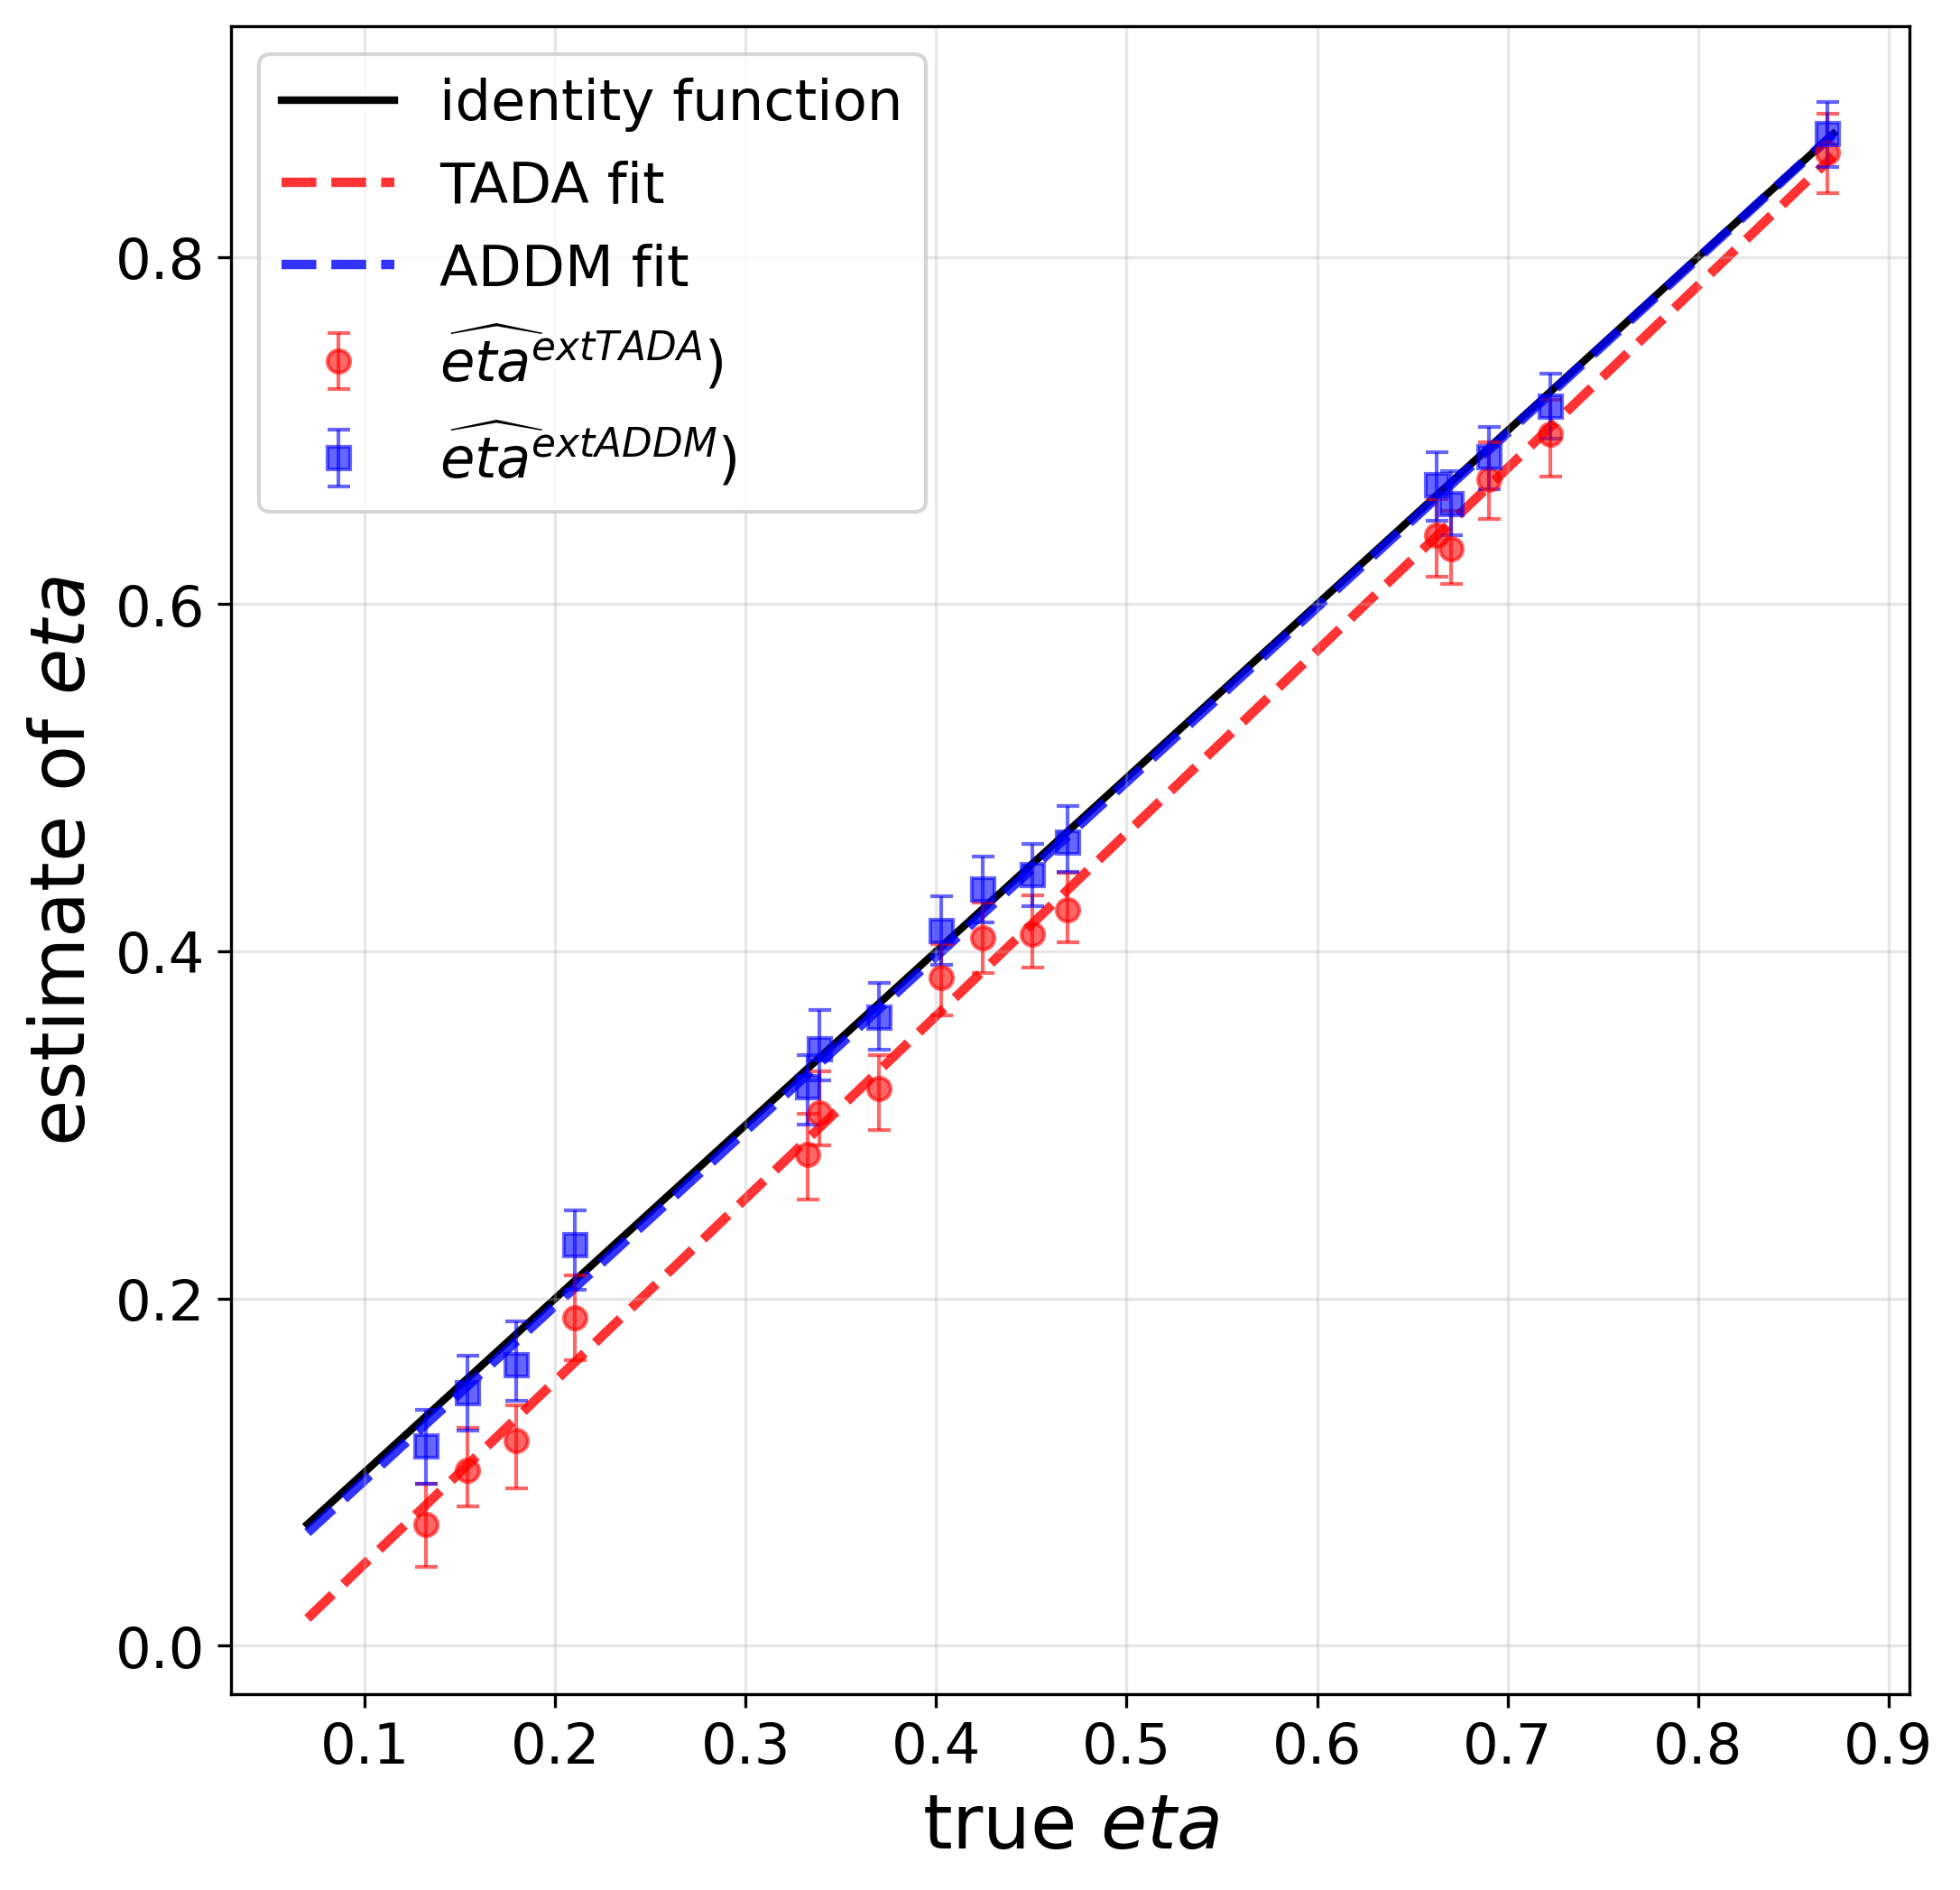

Parameter: kappa | TADA HDI: Yes | ADDM HDI: Yes
Skipping parameter 'kappa' - insufficient variation in true values (std=0.00e+00)
Parameter: a | TADA HDI: Yes | ADDM HDI: Yes
Skipping parameter 'a' - insufficient variation in true values (std=0.00e+00)
Parameter: x0 | TADA HDI: No | ADDM HDI: No
Skipping parameter 'x0' - insufficient variation in true values (std=0.00e+00)


In [7]:
# Generate parameter recovery plots for all parameters
import os

# Extract unique parameters from the CSV columns
# Parameters are identified by columns with "true_" prefix
def plot_param_recovery(param_recovery_df):
    true_params = [col.replace('true_', '') for col in param_recovery_df.columns if col.startswith('true_')]
    print(f"Found parameters: {true_params}")

    # Create a plot for each parameter
    for param in true_params:
        # Get data for this parameter
        true_col = f'true_{param}'
        tada_col = f'tada_{param}'
        addm_col = f'addm_{param}'
        
        true_vals = param_recovery_df[true_col].values
        tada_vals = param_recovery_df[tada_col].values
        addm_vals = param_recovery_df[addm_col].values
        
        # Check for HDI confidence interval columns
        tada_hdi_3_col = f'tada_{param}_hdi_3%'
        tada_hdi_97_col = f'tada_{param}_hdi_97%'
        addm_hdi_3_col = f'addm_{param}_hdi_3%'
        addm_hdi_97_col = f'addm_{param}_hdi_97%'
        
        # Check if HDI columns exist
        has_tada_hdi = (tada_hdi_3_col in param_recovery_df.columns and 
                        tada_hdi_97_col in param_recovery_df.columns)
        has_addm_hdi = (addm_hdi_3_col in param_recovery_df.columns and 
                        addm_hdi_97_col in param_recovery_df.columns)
        
        print(f"Parameter: {param} | TADA HDI: {'Yes' if has_tada_hdi else 'No'} | ADDM HDI: {'Yes' if has_addm_hdi else 'No'}")
        if has_tada_hdi:
            tada_hdi_lower = param_recovery_df[tada_hdi_3_col].values
            tada_hdi_upper = param_recovery_df[tada_hdi_97_col].values
            tada_yerr = np.array([tada_vals - tada_hdi_lower, tada_hdi_upper - tada_vals])
        
        if has_addm_hdi:
            addm_hdi_lower = param_recovery_df[addm_hdi_3_col].values
            addm_hdi_upper = param_recovery_df[addm_hdi_97_col].values
            addm_yerr = np.array([addm_vals - addm_hdi_lower, addm_hdi_upper - addm_vals])
        
        # Check if there's sufficient variation in true values
        true_std = np.std(true_vals)
        if true_std < 1e-6:
            print(f"Skipping parameter '{param}' - insufficient variation in true values (std={true_std:.2e})")
            continue
        
        fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)
        
        # Get min and max values for the identity line
        all_vals = np.concatenate([true_vals, tada_vals, addm_vals])
        min_val = all_vals.min()
        max_val = all_vals.max()
        print("This is the min_val", min_val)
        print("This is the max_val", max_val)
        
        # Plot identity line first (so it appears behind scatter points)
        identity_vals = np.linspace(min_val, max_val, 100)
        ax.plot(identity_vals, identity_vals, c="k", label="identity function", linewidth=2, zorder=0)
        
        # Calculate R² values (with safeguard against division by zero)
        # ss_res_tada = np.sum((true_vals - tada_vals) ** 2)
        # ss_res_addm = np.sum((true_vals - addm_vals) ** 2)
        # ss_tot = np.sum((true_vals - np.mean(true_vals)) ** 2)
        
        # if ss_tot > 0:
        #     r2_tada = 1 - (ss_res_tada / ss_tot)
        #     r2_addm = 1 - (ss_res_addm / ss_tot)
        # else:
        #     r2_tada = np.nan
        #     r2_addm = np.nan
        #     print(f"Warning: ss_tot is zero for parameter '{param}'")

        # calculate regression lines 
        tada_coeffs = np.polyfit(true_vals, tada_vals, 1)
        tada_fit_vals = np.polyval(tada_coeffs, identity_vals)
        
        # ADDM regression line
        addm_coeffs = np.polyfit(true_vals, addm_vals, 1)
        addm_fit_vals = np.polyval(addm_coeffs, identity_vals)
        
        # Plot regression lines
        ax.plot(identity_vals, tada_fit_vals, c="red", linewidth=2.5, zorder=1, linestyle="--", alpha=0.8, label=f"TADA fit")
        ax.plot(identity_vals, addm_fit_vals, c="blue", linewidth=2.5, zorder=1, linestyle="--", alpha=0.8, label=f"ADDM fit")
        
        # Scatter plot for TADA estimates with confidence intervals
        if has_tada_hdi:
            ax.errorbar(
                true_vals,
                tada_vals,
                yerr=tada_yerr,
                fmt='o',
                label=f"$\widehat{{{param}}}^{{\text{{TADA}}}}$)",
                color="red",
                alpha=0.6,
                markersize=6,
                capsize=3,
                capthick=1,
                elinewidth=1,
                zorder=2
            )
        else:
            ax.scatter(
                true_vals,
                tada_vals,
                label=f"$\widehat{{{param}}}^{{\text{{TADA}}}}$)",
                color="red",
                alpha=0.6,
                s=50,
                zorder=2
            )
        
        # Scatter plot for ADDM estimates with confidence intervals
        if has_addm_hdi:
            ax.errorbar(
                true_vals,
                addm_vals,
                yerr=addm_yerr,
                fmt='s',
                label=f"$\widehat{{{param}}}^{{\text{{ADDM}}}}$)",
                color="blue",
                alpha=0.6,
                markersize=6,
                capsize=3,
                capthick=1,
                elinewidth=1,
                zorder=2
            )
        else:
            ax.scatter(
                true_vals,
                addm_vals,
                label=f"$\widehat{{{param}}}^{{\text{{ADDM}}}}$)",
                color="blue",
                alpha=0.6,
                s=50,
                zorder=2
            )
        
        # Labels and formatting
        ax.legend(fontsize=15)
        ax.set_xlabel(f"true ${param}$", fontsize=20)
        ax.set_ylabel(f"estimate of ${param}$", fontsize=20)
        ax.tick_params(axis="both", labelsize=15)
        ax.grid(True, alpha=0.3)
        
        # Save figure
        # os.makedirs("param_recovery_plots", exist_ok=True)s
        # plt.savefig(f"param_recovery_plots/param_recovery_{param}.png", bbox_inches="tight")
        plt.show()

    # print("Parameter recovery plots saved to param_recovery_plots/")
plot_param_recovery(param_recovery_15_clean)

In [8]:
# plot_param_recovery(param_recovery_250)

Found parameters: ['eta', 'kappa', 'a', 'x0']
Parameter: eta | TADA HDI: Yes | ADDM HDI: Yes
Skipping parameter 'eta' - insufficient variation in true values (std=0.00e+00)
Parameter: kappa | TADA HDI: Yes | ADDM HDI: Yes
This is the min_val 0.0209631849727163
This is the max_val 2.264


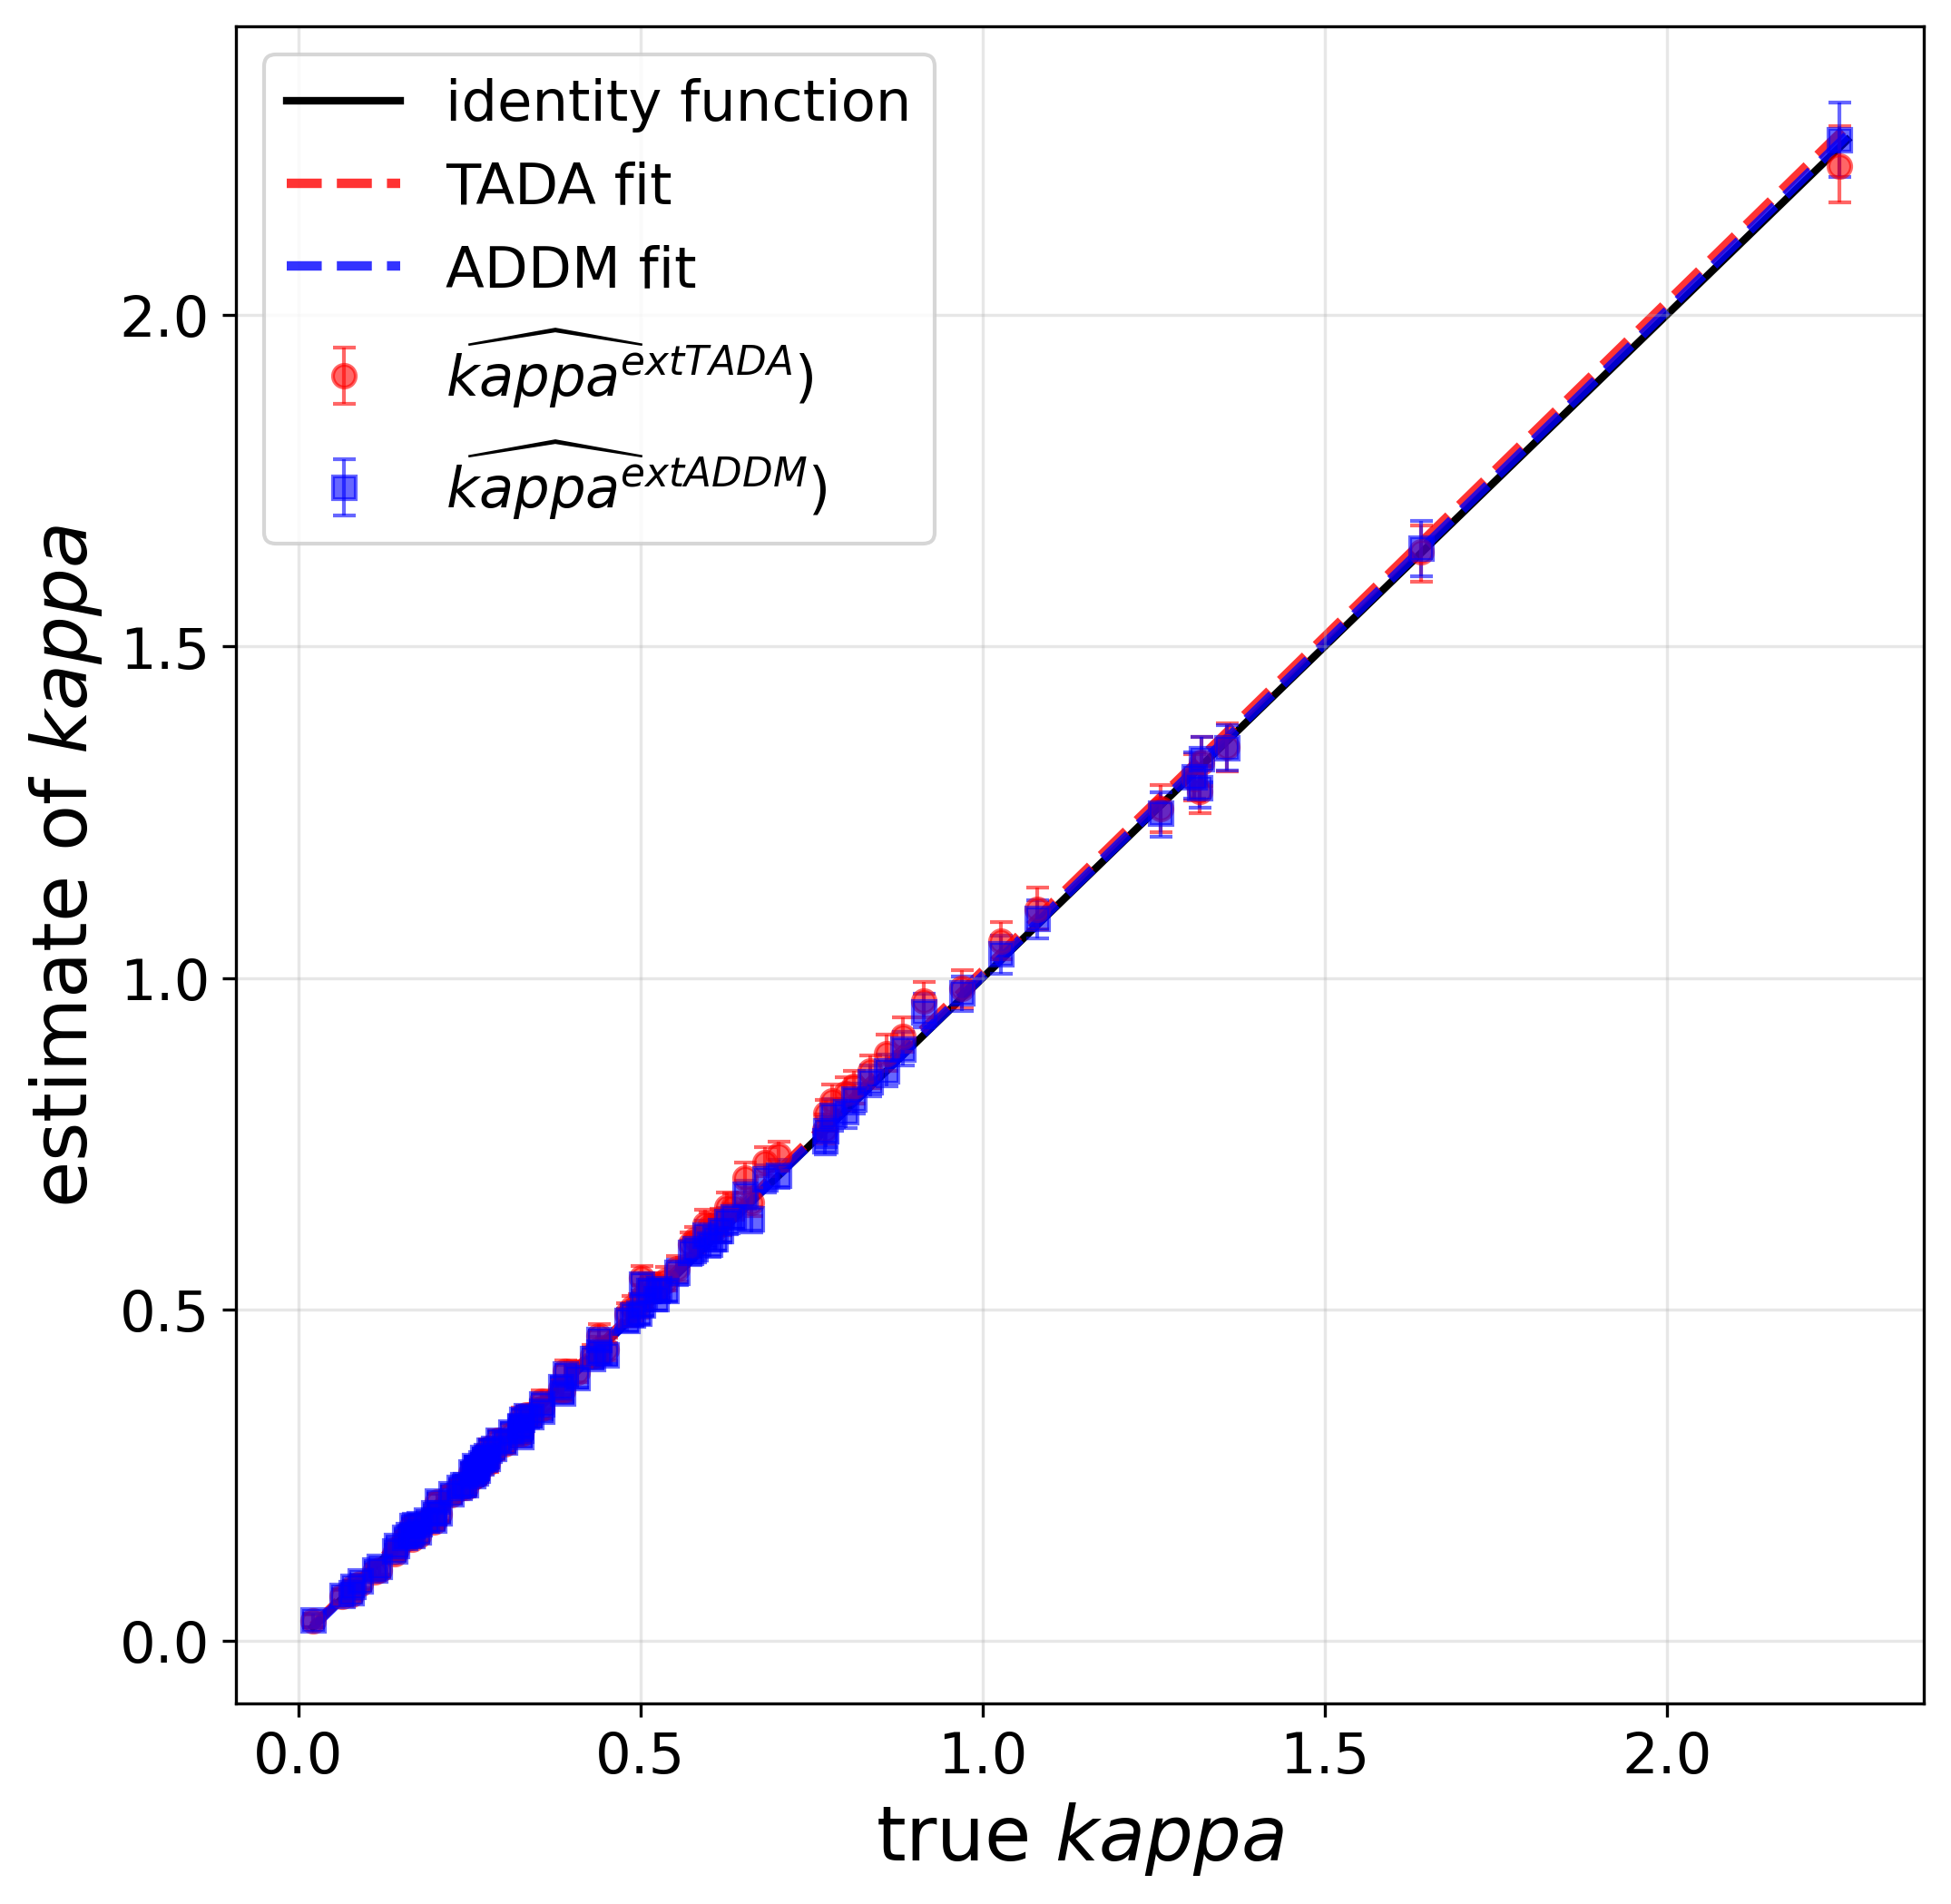

Parameter: a | TADA HDI: Yes | ADDM HDI: Yes
Skipping parameter 'a' - insufficient variation in true values (std=0.00e+00)
Parameter: x0 | TADA HDI: Yes | ADDM HDI: Yes
Skipping parameter 'x0' - insufficient variation in true values (std=0.00e+00)


In [9]:
plot_param_recovery(param_recovery_kappa_simulate_2_clean)

Found parameters: ['eta', 'kappa', 'a', 'x0']
Parameter: eta | TADA HDI: Yes | ADDM HDI: Yes
Skipping parameter 'eta' - insufficient variation in true values (std=1.11e-16)
Parameter: kappa | TADA HDI: Yes | ADDM HDI: Yes
Skipping parameter 'kappa' - insufficient variation in true values (std=0.00e+00)
Parameter: a | TADA HDI: Yes | ADDM HDI: Yes
Skipping parameter 'a' - insufficient variation in true values (std=0.00e+00)
Parameter: x0 | TADA HDI: Yes | ADDM HDI: Yes
This is the min_val -1.5796422221850206
This is the max_val 1.1698560000000002


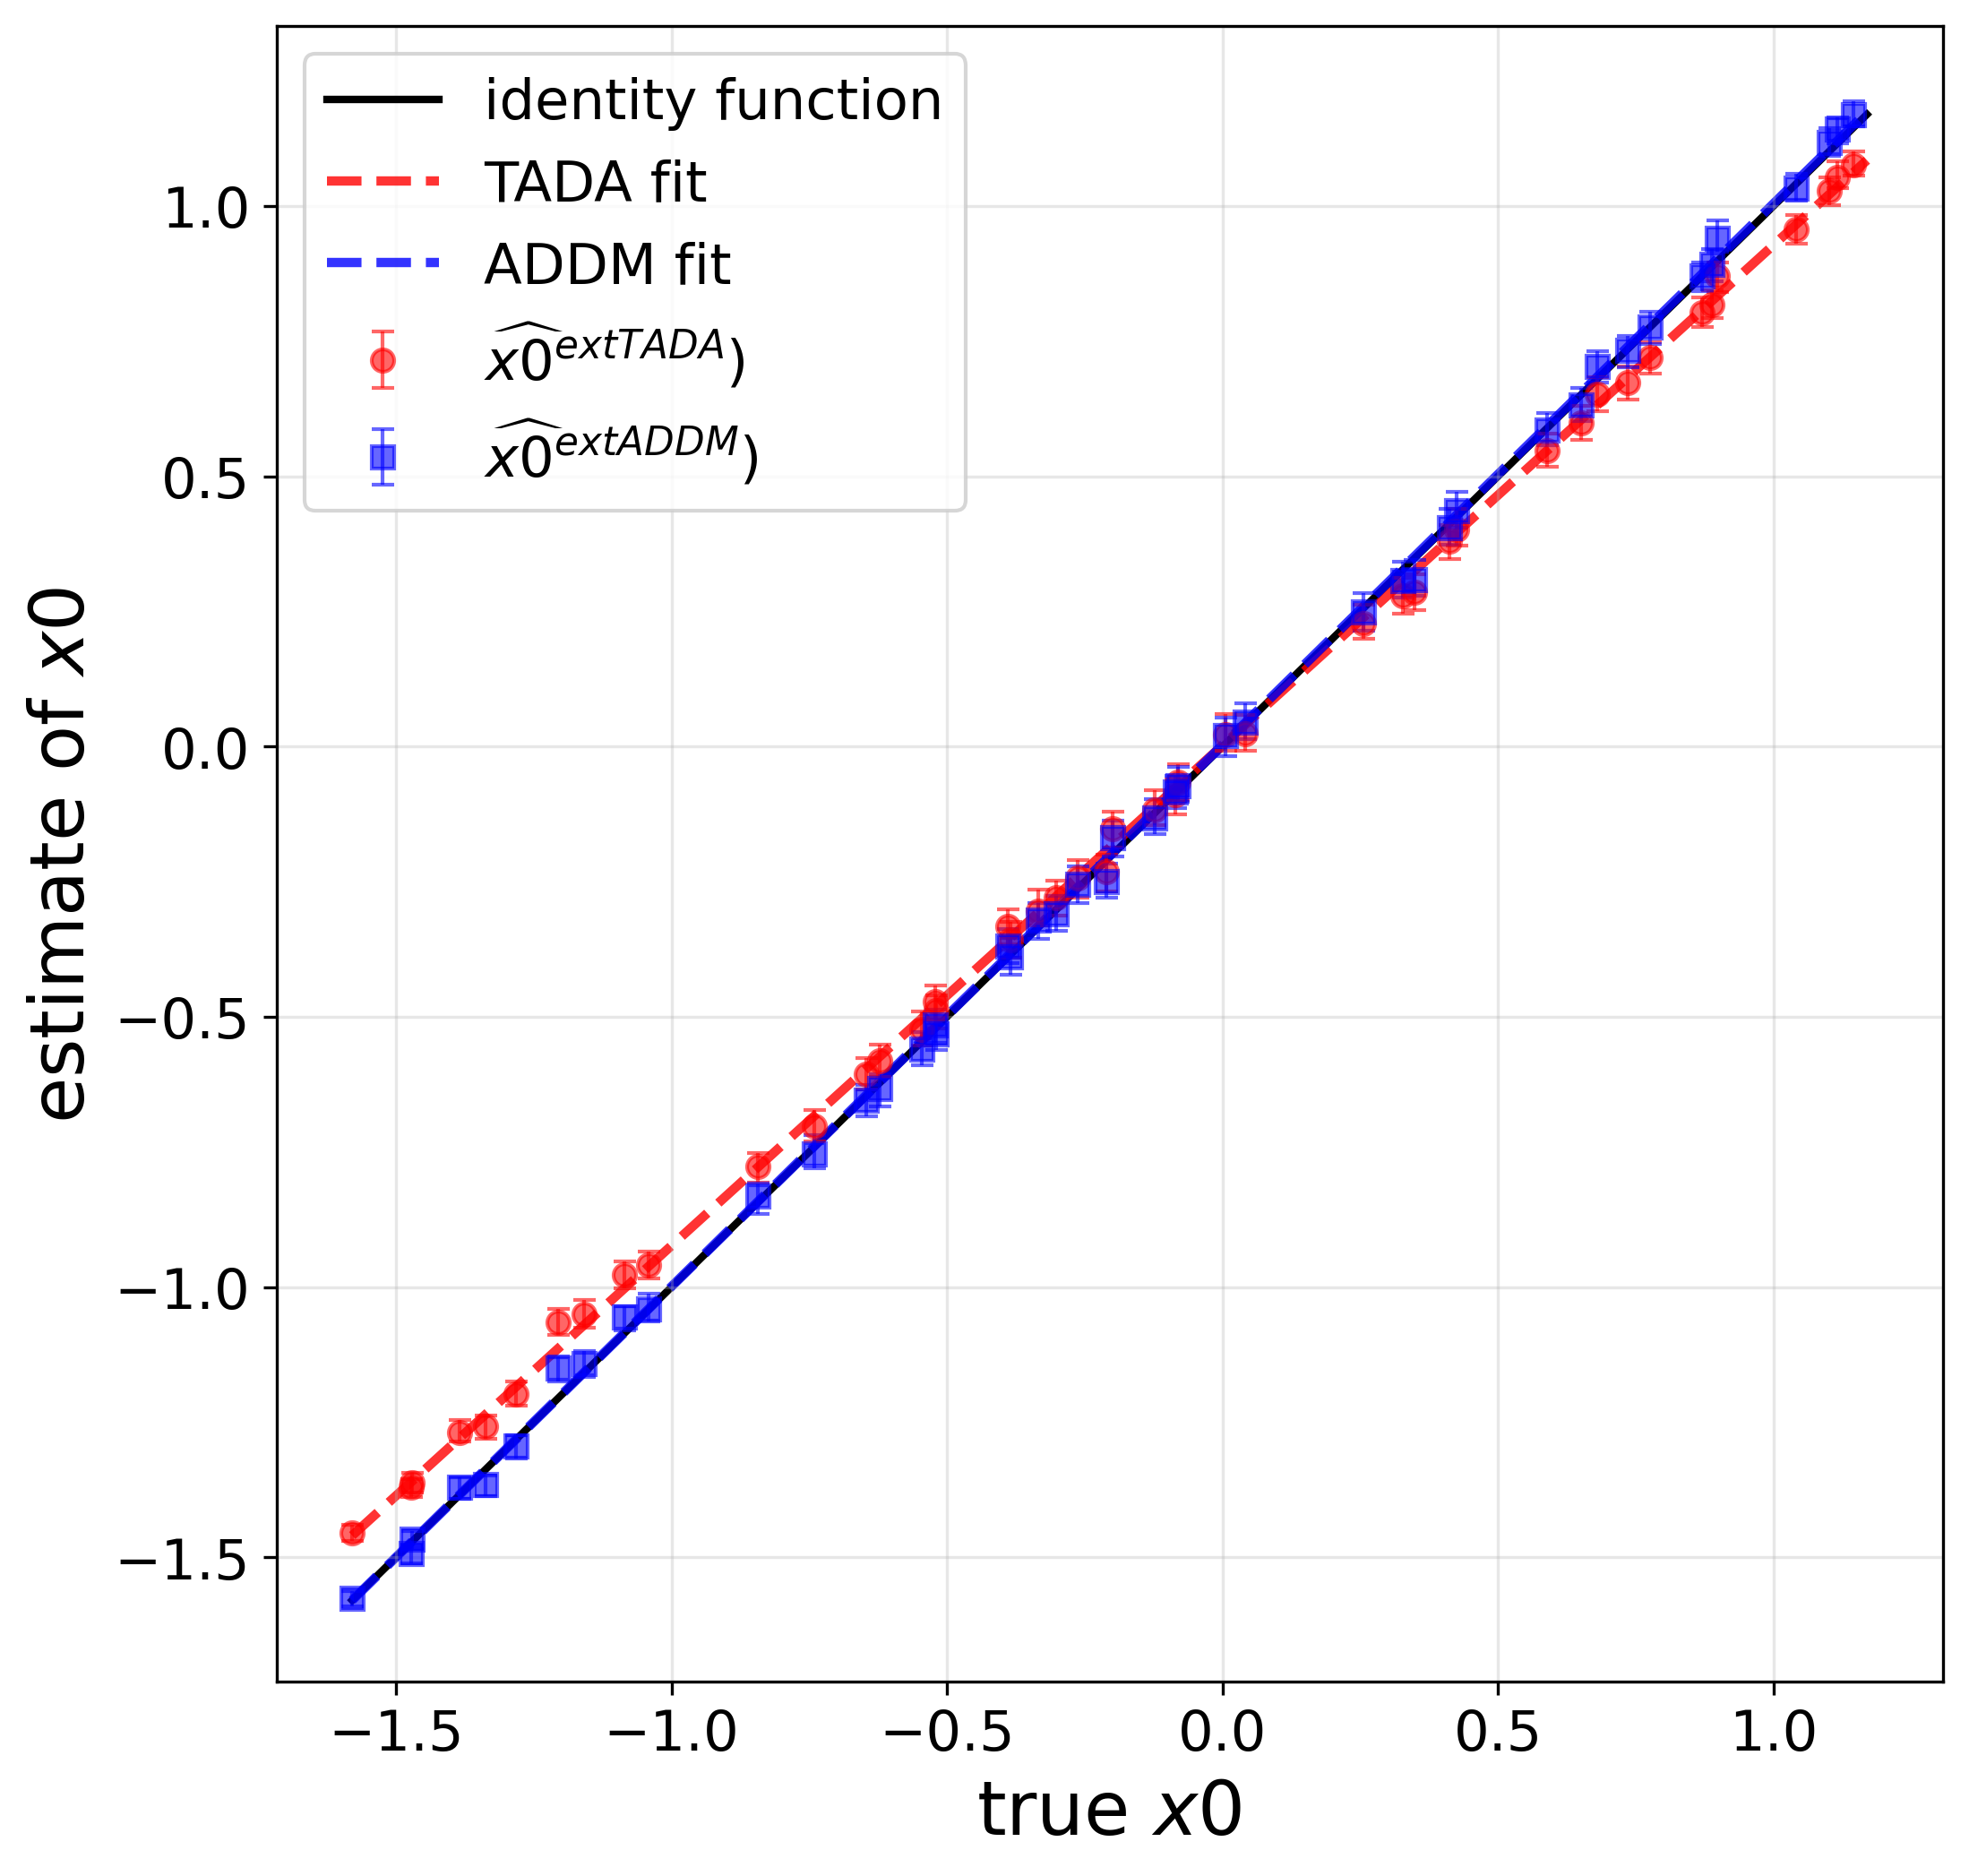

In [10]:
plot_param_recovery(param_recovery_x0_simulate_2_clean)

Found parameters: ['eta', 'kappa', 'a', 'x0']
Parameter: eta | TADA HDI: Yes | ADDM HDI: Yes
Skipping parameter 'eta' - insufficient variation in true values (std=5.55e-17)
Parameter: kappa | TADA HDI: Yes | ADDM HDI: Yes
Skipping parameter 'kappa' - insufficient variation in true values (std=0.00e+00)
Parameter: a | TADA HDI: Yes | ADDM HDI: Yes
This is the min_val 0.592
This is the max_val 6.301365186834418


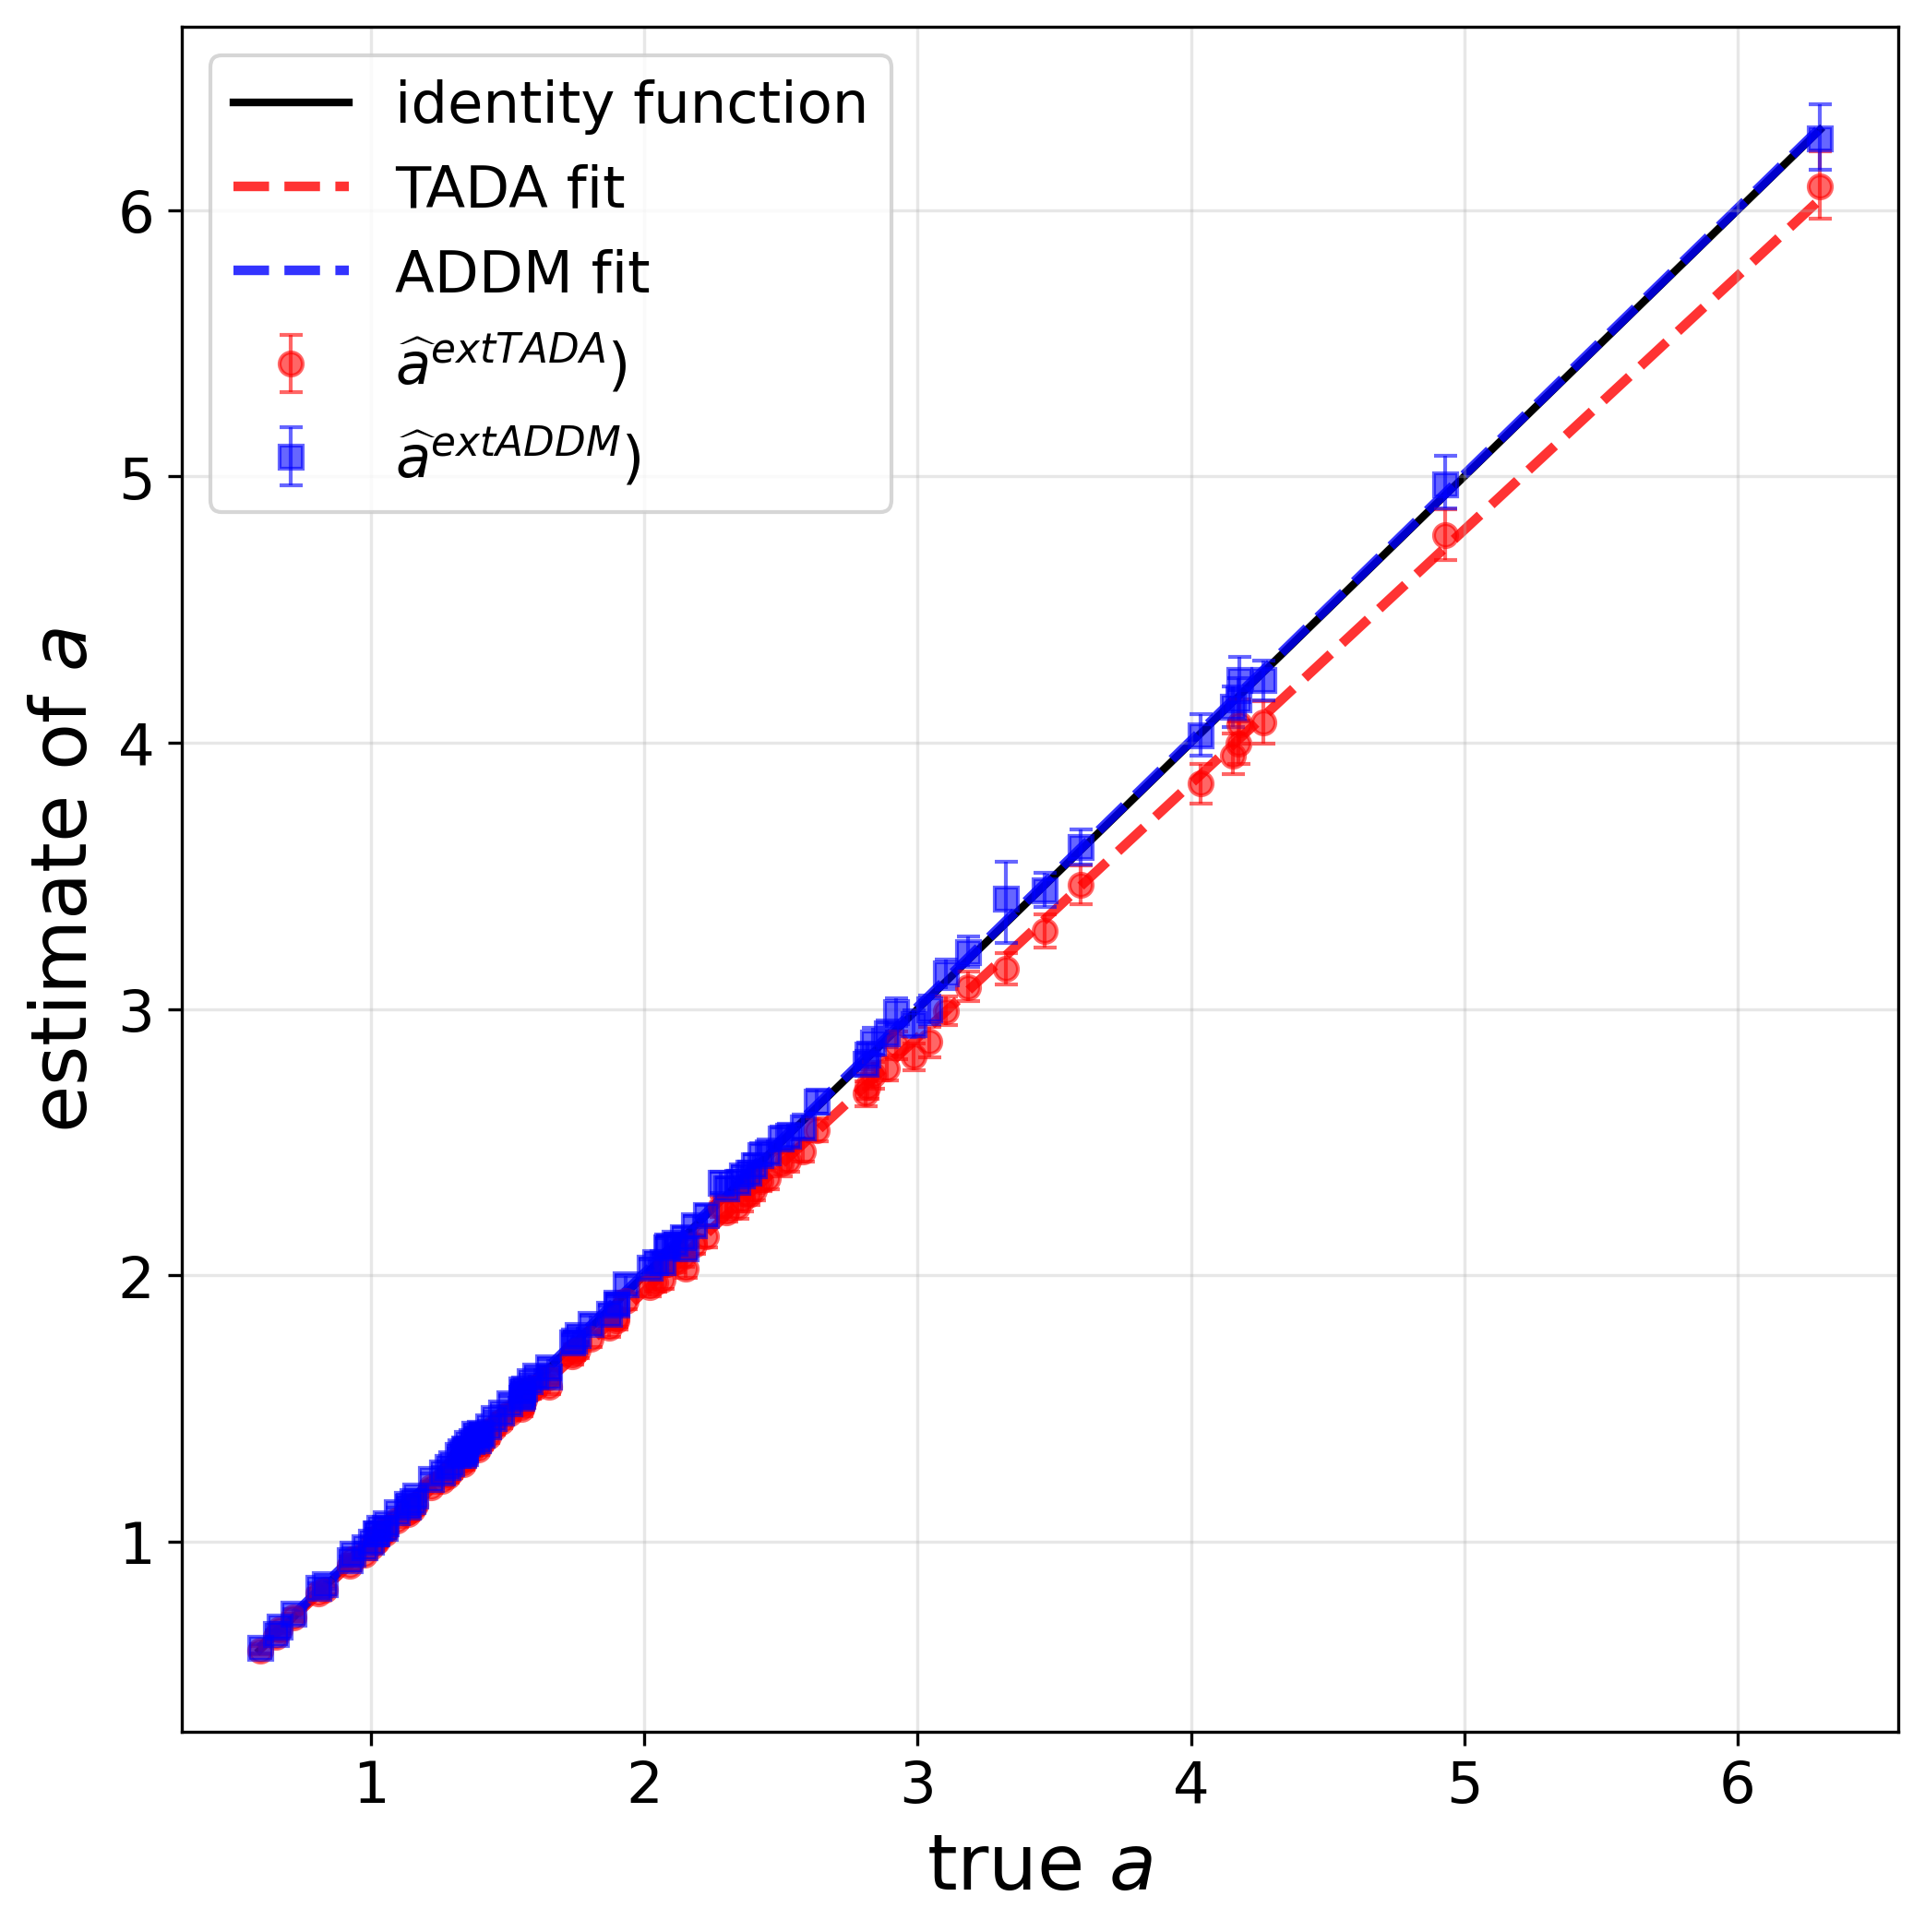

Parameter: x0 | TADA HDI: Yes | ADDM HDI: Yes
Skipping parameter 'x0' - insufficient variation in true values (std=0.00e+00)


In [11]:
plot_param_recovery(param_recovery_a_simulate_2_clean)

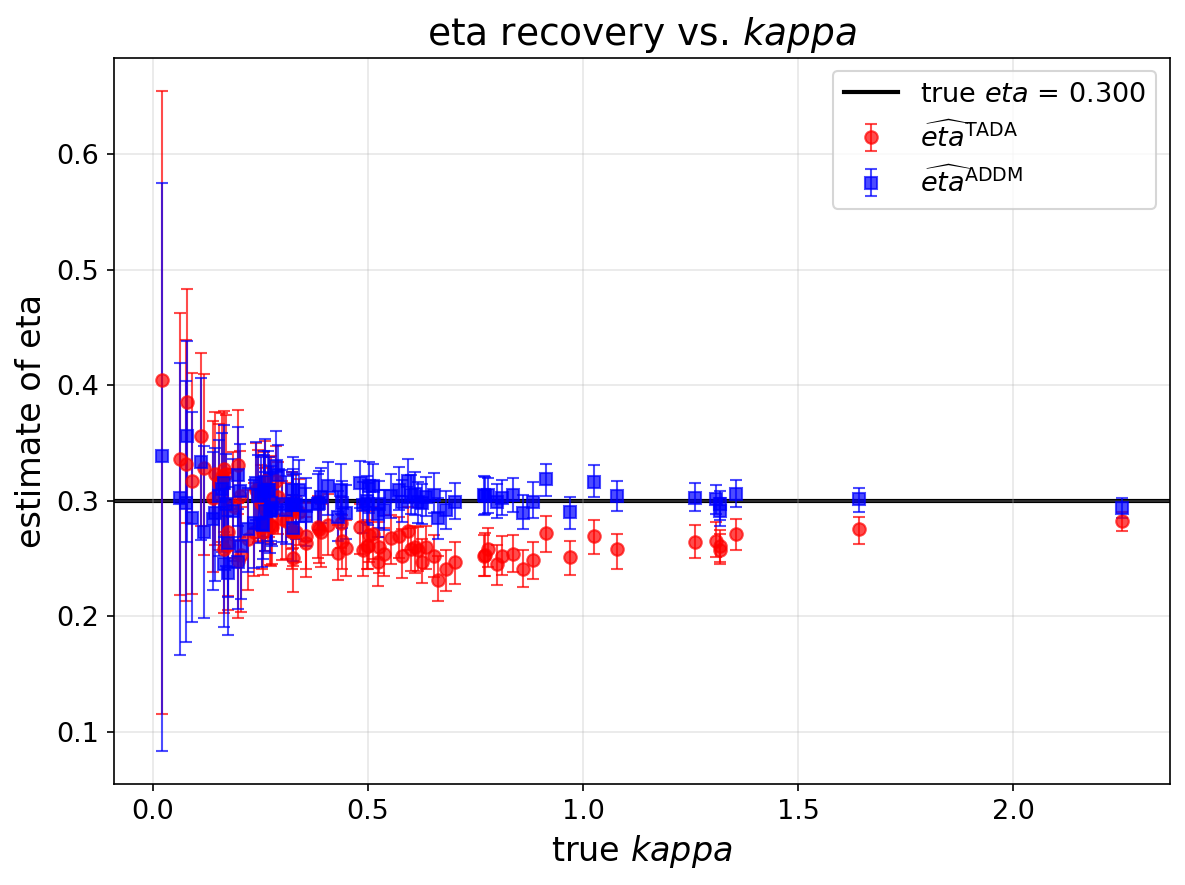

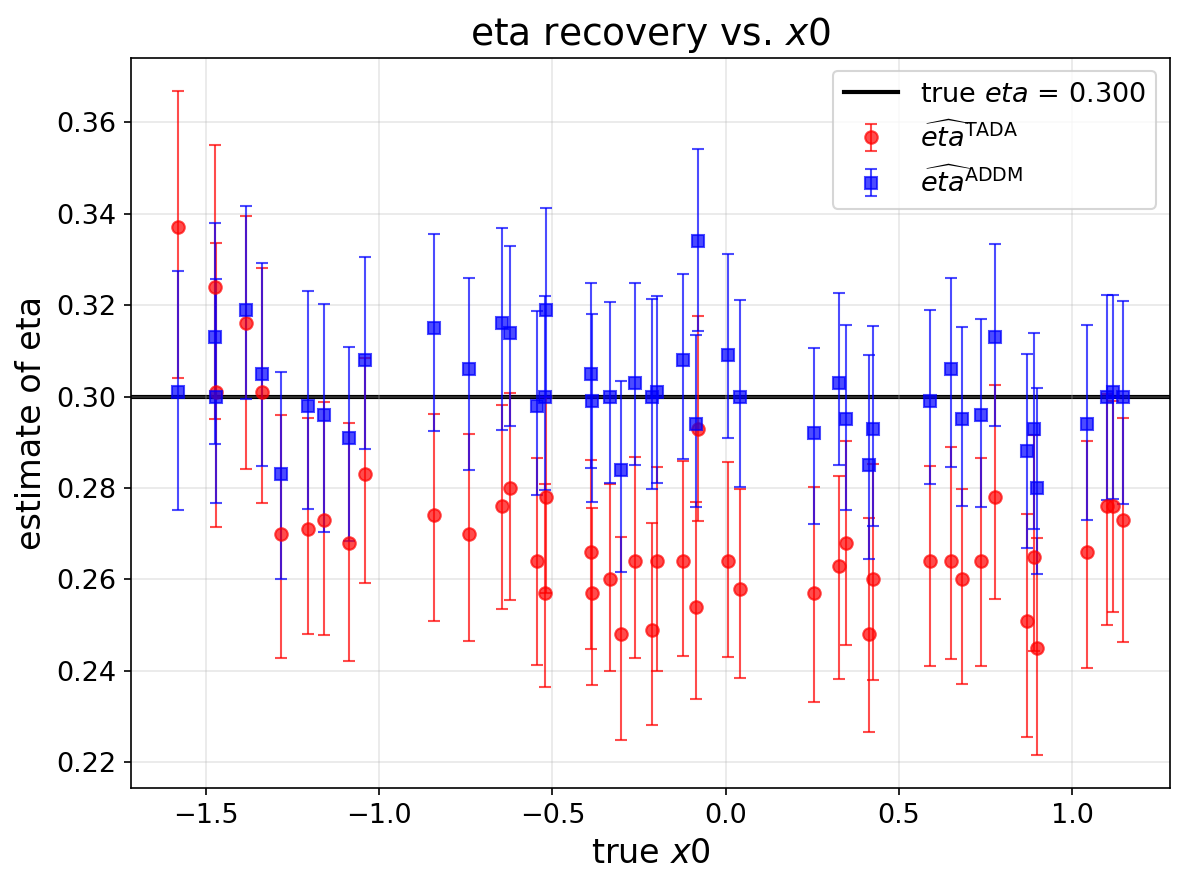

<Figure size 640x480 with 0 Axes>

In [12]:
def plot_eta_recovery_vs_param(param_recovery_df, varied_param, ax=None, title=None):
    """
    Plot eta recovery (y-axis) against the simulated value of a varied parameter (x-axis).
    
    Args:
        param_recovery_df: DataFrame with recovery results
        varied_param: name of the parameter that was varied (e.g., 'kappa', 'x0', 'a')
        ax: optional matplotlib axis; if None, creates a new figure
        title: optional title for the plot
    """
    true_varied_col = f'true_{varied_param}'
    true_eta_col = 'true_eta'
    tada_eta_col = 'tada_eta'
    addm_eta_col = 'addm_eta'
    
    # HDI columns for eta
    tada_hdi_3_col = 'tada_eta_hdi_3%'
    tada_hdi_97_col = 'tada_eta_hdi_97%'
    addm_hdi_3_col = 'addm_eta_hdi_3%'
    addm_hdi_97_col = 'addm_eta_hdi_97%'
    
    has_tada_hdi = tada_hdi_3_col in param_recovery_df.columns and tada_hdi_97_col in param_recovery_df.columns
    has_addm_hdi = addm_hdi_3_col in param_recovery_df.columns and addm_hdi_97_col in param_recovery_df.columns
    
    x_vals = param_recovery_df[true_varied_col].values
    tada_eta = param_recovery_df[tada_eta_col].values
    addm_eta = param_recovery_df[addm_eta_col].values
    true_eta = param_recovery_df[true_eta_col].values  # should be constant
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6), dpi=150)
        standalone = True
    else:
        standalone = False
    
    # Horizontal line at true eta (take mean in case of floating point noise)
    true_eta_val = np.mean(true_eta)
    ax.axhline(true_eta_val, color='black', linewidth=2, linestyle='-', label=f'true $eta$ = {true_eta_val:.3f}', zorder=0)
    
    # TADA eta estimates
    if has_tada_hdi:
        tada_lower = param_recovery_df[tada_hdi_3_col].values
        tada_upper = param_recovery_df[tada_hdi_97_col].values
        tada_yerr = np.array([tada_eta - tada_lower, tada_upper - tada_eta])
        ax.errorbar(x_vals, tada_eta, yerr=tada_yerr,
                    fmt='o', color='red', alpha=0.7, markersize=6,
                    capsize=3, capthick=1, elinewidth=1,
                    label=r'$\widehat{eta}^{\mathrm{TADA}}$', zorder=2)
    else:
        ax.scatter(x_vals, tada_eta, color='red', alpha=0.7, s=50,
                   label=r'$\widehat{eta}^{\mathrm{TADA}}$', zorder=2)
    
    # ADDM eta estimates
    if has_addm_hdi:
        addm_lower = param_recovery_df[addm_hdi_3_col].values
        addm_upper = param_recovery_df[addm_hdi_97_col].values
        addm_yerr = np.array([addm_eta - addm_lower, addm_upper - addm_eta])
        ax.errorbar(x_vals, addm_eta, yerr=addm_yerr,
                    fmt='s', color='blue', alpha=0.7, markersize=6,
                    capsize=3, capthick=1, elinewidth=1,
                    label=r'$\widehat{eta}^{\mathrm{ADDM}}$', zorder=2)
    else:
        ax.scatter(x_vals, addm_eta, color='blue', alpha=0.7, s=50,
                   label=r'$\widehat{eta}^{\mathrm{ADDM}}$', zorder=2)
    
    ax.set_xlabel(f'true ${varied_param}$', fontsize=16)
    ax.set_ylabel(r'estimate of eta', fontsize=16)
    ax.set_title(title or f'eta recovery vs. ${varied_param}$', fontsize=18)
    ax.legend(fontsize=13)
    ax.tick_params(axis='both', labelsize=13)
    ax.grid(True, alpha=0.3)
    
    if standalone:
        plt.tight_layout()
        plt.show()


# --- Plot all three side by side ---
# fig, axes = plt.subplots(1, 3, figsize=(22, 7), dpi=150)

plot_eta_recovery_vs_param(param_recovery_kappa_simulate_2_clean, 'kappa')
plot_eta_recovery_vs_param(param_recovery_x0_simulate_2_clean,    'x0')

# fig.suptitle(r'Recovery of eta across varied parameter simulations', fontsize=20, y=1.02)
plt.tight_layout()
# plt.savefig("eta_recovery_vs_params.png", bbox_inches="tight")
plt.show()

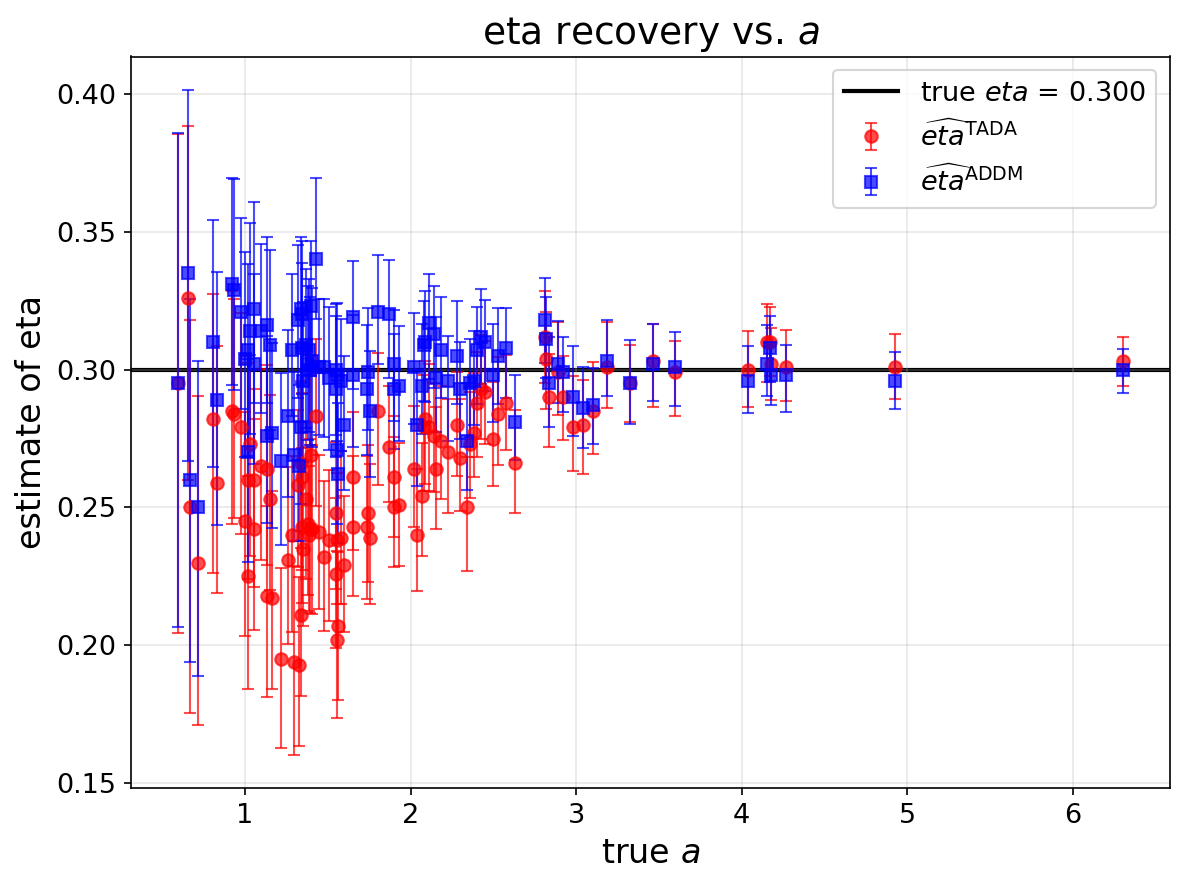

In [14]:
plot_eta_recovery_vs_param(param_recovery_a_simulate_2_clean,'a')
